In [2]:
print('test')

test


Generating Perlin noise terrain...


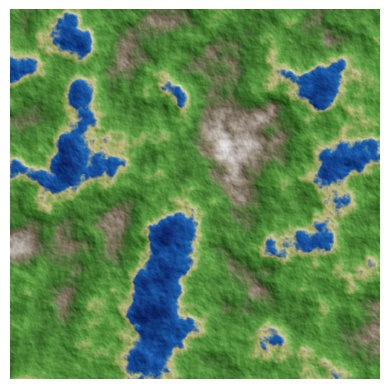

Saved: images/terrain_map.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from noise import pnoise2

# --- Config ---
WIDTH, HEIGHT = 512, 512
SCALE = 4.0          # lower = zoomed in / smoother
OCTAVES = 8          # detail layers
PERSISTENCE = 0.5    # amplitude decay per octave
LACUNARITY = 2.0     # frequency growth per octave
SEED = 42

rng = np.random.default_rng(SEED)


def generate_perlin(width, height, scale, octaves, persistence, lacunarity, seed):
    """Generate a 2D Perlin noise array in [0, 1]."""
    base = seed % 256
    terrain = np.zeros((height, width))
    for y in range(height):
        for x in range(width):
            terrain[y, x] = pnoise2(
                x / width * scale,
                y / height * scale,
                octaves=octaves,
                persistence=persistence,
                lacunarity=lacunarity,
                base=base,
            )
    # Normalise to [0, 1]
    terrain = (terrain - terrain.min()) / (terrain.max() - terrain.min())
    return terrain


def make_terrain_colormap():
    """Custom colormap: deep water → shallow → sand → grass → rock → snow."""
    colors = [
        (0.05, 0.15, 0.40),   # deep water
        (0.10, 0.35, 0.65),   # shallow water
        (0.76, 0.72, 0.50),   # sand
        (0.35, 0.60, 0.25),   # lowland grass
        (0.25, 0.45, 0.18),   # highland grass
        (0.50, 0.45, 0.38),   # rock
        (0.90, 0.90, 0.90),   # snow
    ]
    positions = [0.0, 0.25, 0.30, 0.40, 0.60, 0.75, 1.0]
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "terrain_custom",
        list(zip(positions, colors)),
    )
    return cmap


def plot_terrain(terrain):
    cmap = make_terrain_colormap()

    # --- hillshaded ---
    plt.figure()
    ls = mcolors.LightSource(azdeg=315, altdeg=35)
    hillshade = ls.shade(terrain, cmap=cmap, vert_exag=3.0, blend_mode="soft")
    plt.imshow(hillshade, origin="lower", interpolation="bilinear")
    plt.axis("off")

    plt.savefig("images/terrain_map.png", dpi=150,)
    plt.show()
    print("Saved: images/terrain_map.png")


if __name__ == "__main__":
    print("Generating Perlin noise terrain...")
    terrain = generate_perlin(WIDTH, HEIGHT, SCALE, OCTAVES, PERSISTENCE, LACUNARITY, SEED)

    plot_terrain(terrain)

Left path (6 nodes): [3, 4, 0, 2, 10, 1]
Right path (7 nodes): [17, 5, 23, 21, 15, 33, 22]


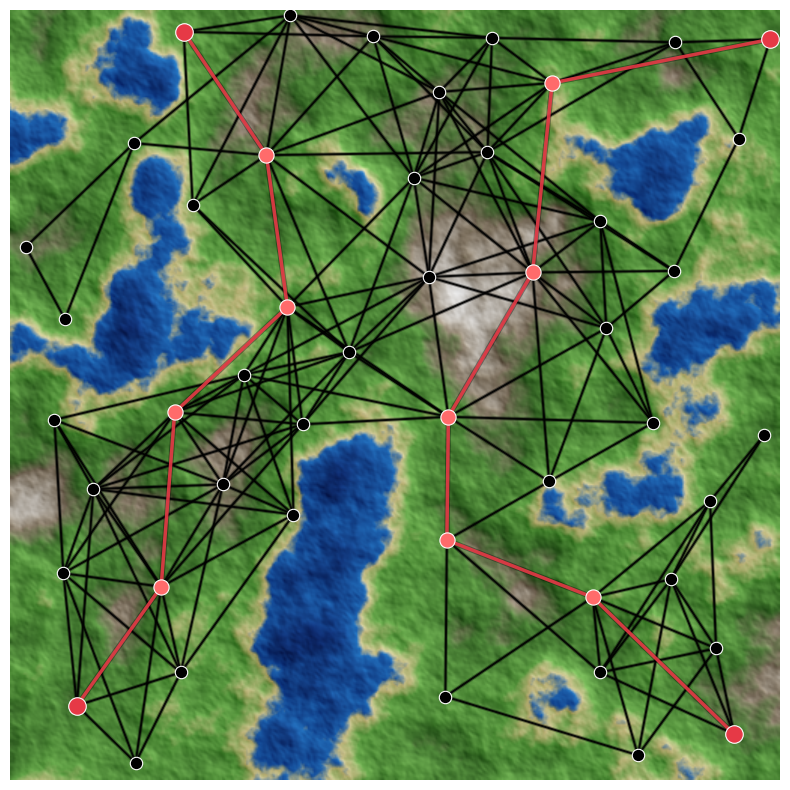

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from collections import deque
from noise import pnoise2

# --- Config ---
WIDTH, HEIGHT = 512, 512
SCALE = 4.0
OCTAVES = 8
PERSISTENCE = 0.5
LACUNARITY = 2.0
SEED = 42

N_NODES = 50
WATER_THRESHOLD = 0.30
SLOPE_THRESHOLD = 0.15
MAX_EDGE_DIST = 150
MIN_SEP = 50
MAX_SEP = 150

rng = np.random.default_rng(SEED)


def generate_perlin(width, height, scale, octaves, persistence, lacunarity, seed):
    base = seed % 256
    terrain = np.zeros((height, width))
    for y in range(height):
        for x in range(width):
            terrain[y, x] = pnoise2(
                x / width * scale,
                y / height * scale,
                octaves=octaves,
                persistence=persistence,
                lacunarity=lacunarity,
                base=base,
            )
    terrain = (terrain - terrain.min()) / (terrain.max() - terrain.min())
    return terrain


def make_terrain_colormap():
    colors = [
        (0.05, 0.15, 0.40),
        (0.10, 0.35, 0.65),
        (0.76, 0.72, 0.50),
        (0.35, 0.60, 0.25),
        (0.25, 0.45, 0.18),
        (0.50, 0.45, 0.38),
        (0.90, 0.90, 0.90),
    ]
    positions = [0.0, 0.25, 0.30, 0.40, 0.60, 0.75, 1.0]
    return mcolors.LinearSegmentedColormap.from_list(
        "terrain_custom", list(zip(positions, colors))
    )


def compute_slope(terrain):
    gy, gx = np.gradient(terrain)
    return np.sqrt(gx**2 + gy**2)


def is_passable(terrain, slope, water_thr, slope_thr):
    return (terrain > water_thr) & (slope < slope_thr)


def sample_nodes_on_passable(passable, n, rng, min_sep=MIN_SEP, max_sep=MAX_SEP,
                              max_attempts=10_000):
    ys, xs = np.where(passable)
    candidates = np.stack([xs, ys], axis=1)
    placed = []
    attempts = 0
    shuffled = rng.permutation(len(candidates))
    for idx in shuffled:
        if len(placed) == n:
            break
        pt = candidates[idx]
        if placed:
            dists = np.linalg.norm(np.array(placed) - pt, axis=1)
            if dists.min() < min_sep:
                continue
        placed.append(pt)
        attempts += 1
        if attempts > max_attempts:
            raise RuntimeError(f"Could only place {len(placed)}/{n} nodes.")
    nodes = np.array(placed)
    dists = np.linalg.norm(nodes[:, None] - nodes[None, :], axis=2)
    np.fill_diagonal(dists, np.inf)
    has_neighbour = dists.min(axis=1) <= max_sep
    nodes = nodes[has_neighbour]
    return nodes


def edge_is_passable(p1, p2, passable, samples=80):
    xs = np.linspace(p1[0], p2[0], samples).astype(int)
    ys = np.linspace(p1[1], p2[1], samples).astype(int)
    xs = np.clip(xs, 0, passable.shape[1] - 1)
    ys = np.clip(ys, 0, passable.shape[0] - 1)
    return passable[ys, xs].all()


def build_graph(nodes, passable, max_dist):
    n = len(nodes)
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(nodes[i] - nodes[j])
            if dist > max_dist:
                continue
            if edge_is_passable(nodes[i], nodes[j], passable):
                edges.append((i, j))
    return edges


def find_corner_nodes(nodes):
    """Return indices of nodes closest to each image corner."""
    corners = {
        "bottom_left":  np.array([0,     0]),
        "top_left":     np.array([0,     HEIGHT]),
        "bottom_right": np.array([WIDTH, 0]),
        "top_right":    np.array([WIDTH, HEIGHT]),
    }
    return {name: int(np.argmin(np.linalg.norm(nodes - c, axis=1)))
            for name, c in corners.items()}


def bfs_path(src, dst, edges, n_nodes):
    """BFS shortest path between src and dst. Returns node list or None."""
    adj = {i: [] for i in range(n_nodes)}
    for i, j in edges:
        adj[i].append(j)
        adj[j].append(i)
    queue = deque([[src]])
    visited = {src}
    while queue:
        path = queue.popleft()
        if path[-1] == dst:
            return path
        for nb in adj[path[-1]]:
            if nb not in visited:
                visited.add(nb)
                queue.append(path + [nb])
    return None


def path_to_edgeset(path):
    return {(min(a, b), max(a, b)) for a, b in zip(path[:-1], path[1:])}


def plot(terrain, passable, nodes, edges):
    cmap = make_terrain_colormap()
    ls = mcolors.LightSource(azdeg=315, altdeg=35)
    hillshade = ls.shade(terrain, cmap=cmap, vert_exag=3.0, blend_mode="soft")

    corners = find_corner_nodes(nodes)
    left_path  = bfs_path(corners["bottom_left"],  corners["top_left"],  edges, len(nodes))
    right_path = bfs_path(corners["bottom_right"], corners["top_right"], edges, len(nodes))

    highlight = set()
    if left_path:
        highlight |= path_to_edgeset(left_path)
        print(f"Left path ({len(left_path)} nodes): {left_path}")
    else:
        print("No left path found.")
    if right_path:
        highlight |= path_to_edgeset(right_path)
        print(f"Right path ({len(right_path)} nodes): {right_path}")
    else:
        print("No right path found.")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(hillshade, origin="lower", interpolation="bilinear")
    ax.axis("off")

    # Draw edges — highlighted in red, others black
    for i, j in edges:
        key = (min(i, j), max(i, j))
        is_highlight = key in highlight
        x0, y0 = nodes[i]
        x1, y1 = nodes[j]
        color = "#e63946" if is_highlight else "black"
        lw    = 2.5      if is_highlight else 1.4
        zorder = 3       if is_highlight else 2
        ax.plot([x0, x1], [y0, y1], color=color, linewidth=lw,
                alpha=0.9, zorder=zorder,
                path_effects=[pe.Stroke(linewidth=lw + 1.4, foreground="black", alpha=0.35),
                               pe.Normal()])

    # Draw nodes — highlight path nodes
    path_nodes = set()
    if left_path:  path_nodes |= set(left_path)
    if right_path: path_nodes |= set(right_path)
    corner_nodes = set(corners.values())

    for idx, (x, y) in enumerate(nodes):
        if idx in corner_nodes:
            color, size, zorder = "#e63946", 160, 5
        elif idx in path_nodes:
            color, size, zorder = "#ff6b6b", 120, 4
        else:
            color, size, zorder = "black", 80, 3
        ax.scatter(x, y, c=color, s=size, zorder=zorder,
                   edgecolors="white", linewidths=0.8)

    plt.tight_layout()
    plt.savefig("images/terrain_graph.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


if __name__ == "__main__":
    terrain = generate_perlin(WIDTH, HEIGHT, SCALE, OCTAVES, PERSISTENCE, LACUNARITY, SEED)
    slope = compute_slope(terrain)
    passable = is_passable(terrain, slope, WATER_THRESHOLD, SLOPE_THRESHOLD)

    nodes = sample_nodes_on_passable(passable, N_NODES, rng)
    edges = build_graph(nodes, passable, MAX_EDGE_DIST)

    connected = np.array(sorted({i for e in edges for i in e}))
    remap = {old: new for new, old in enumerate(connected)}
    nodes = nodes[connected]
    edges = [(remap[i], remap[j]) for i, j in edges]

    plot(terrain, passable, nodes, edges)